In [25]:
from skrub import Cleaner
from skrub import TableReport as tr

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso, LassoCV, Ridge, RidgeCV, LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score
from sklearn.preprocessing import StandardScaler

from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

from sklearn.pipeline import Pipeline,make_pipeline
from sklearn.impute import SimpleImputer

import seaborn as sns

In [38]:
import warnings
from sklearn.exceptions import ConvergenceWarning

# Ignore ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Nettoyage des données

In [39]:
df = pd.read_csv('AirQualityUCI.csv',sep=';')
df

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578",NaN,NaN
1,10/03/2004,19.00.00,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255",NaN,NaN
2,10/03/2004,20.00.00,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502",NaN,NaN
3,10/03/2004,21.00.00,"2,2",1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867",NaN,NaN
4,10/03/2004,22.00.00,"1,6",1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9466,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9467,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9468,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9469,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [40]:
cleaner = Cleaner()
df = cleaner.fit_transform(df)# enleve les colonnes nuls(les deux dernieres)
df = df.dropna() # enleve les lignes avec des valeurs nulles
df

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10,18.00.00,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578"
1,2004-03-10,19.00.00,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255"
2,2004-03-10,20.00.00,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502"
3,2004-03-10,21.00.00,"2,2",1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867"
4,2004-03-10,22.00.00,"1,6",1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9352,2005-04-04,10.00.00,"3,1",1314.0,-200.0,"13,5",1101.0,472.0,539.0,190.0,1374.0,1729.0,"21,9","29,3","0,7568"
9353,2005-04-04,11.00.00,"2,4",1163.0,-200.0,"11,4",1027.0,353.0,604.0,179.0,1264.0,1269.0,"24,3","23,7","0,7119"
9354,2005-04-04,12.00.00,"2,4",1142.0,-200.0,"12,4",1063.0,293.0,603.0,175.0,1241.0,1092.0,"26,9","18,3","0,6406"
9355,2005-04-04,13.00.00,"2,1",1003.0,-200.0,"9,5",961.0,235.0,702.0,156.0,1041.0,770.0,"28,3","13,5","0,5139"


In [41]:
df_temp = df.copy()
df = df.drop(['Date','Time','NMHC(GT)'],axis=1)
df = df.replace(',','.',regex= True)
df = df.astype(float)

On a maintenant des données utilisable

# Analyse des données

## PCA pout l'analyse

<BarContainer object of 12 artists>

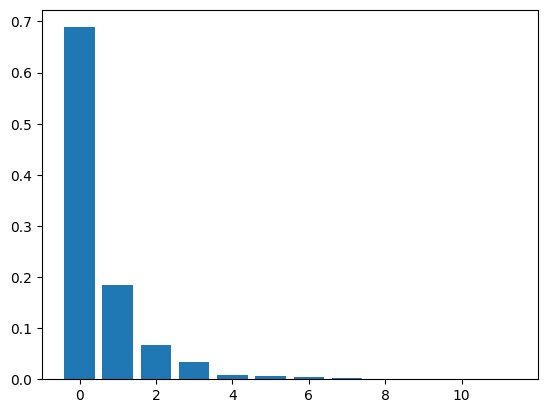

In [30]:
from sklearn.decomposition import PCA
pca = PCA()
pca.fit(df)
inertie = pca.explained_variance_ratio_
plt.bar(range(0,len(inertie)),inertie)

In [31]:
pca = PCA(n_components=2)
projete = pca.fit_transform(df)

print('The principal component is:')
print('The explained variance is %g'%pca.explained_variance_ratio_.sum())


The principal component is:
The explained variance is 0.872673


In [32]:
def plot_correlation_circle(initial_variables, new_variables, feature_names, pc_labels=['PC1', 'PC2']):
    plt.figure(figsize=(8, 8))
    
    # Tracer un cercle unité
    circle = plt.Circle((0, 0), 1, color='gray', fill=False)
    plt.gca().add_artist(circle)
    
    # Tracer les flèches (correlations des variables)
    for i in range(initial_variables.shape[1]):
        x=np.corrcoef(new_variables[:,0],initial_variables.iloc[:,i])[0,1]
        y=np.corrcoef(new_variables[:,1],initial_variables.iloc[:,i])[0,1]
        plt.arrow(0, 0, x, y, head_width=0.05, head_length=0.001, fc='red', ec='red')
        plt.text(x * 1.1, y * 1.1, feature_names[i], color='black', ha='center', va='center')
    
    # Ajustements esthétiques
    plt.axhline(0, color='black', linewidth=0.5)
    plt.axvline(0, color='black', linewidth=0.5)
    plt.xlim(-1.1, 1.1)
    plt.ylim(-1.1, 1.1)
    plt.xlabel(pc_labels[0])
    plt.ylabel(pc_labels[1])
    plt.grid(color='lightgray', linestyle='--', linewidth=0.5)
    plt.title('Cercle de corrélation')
    plt.show()

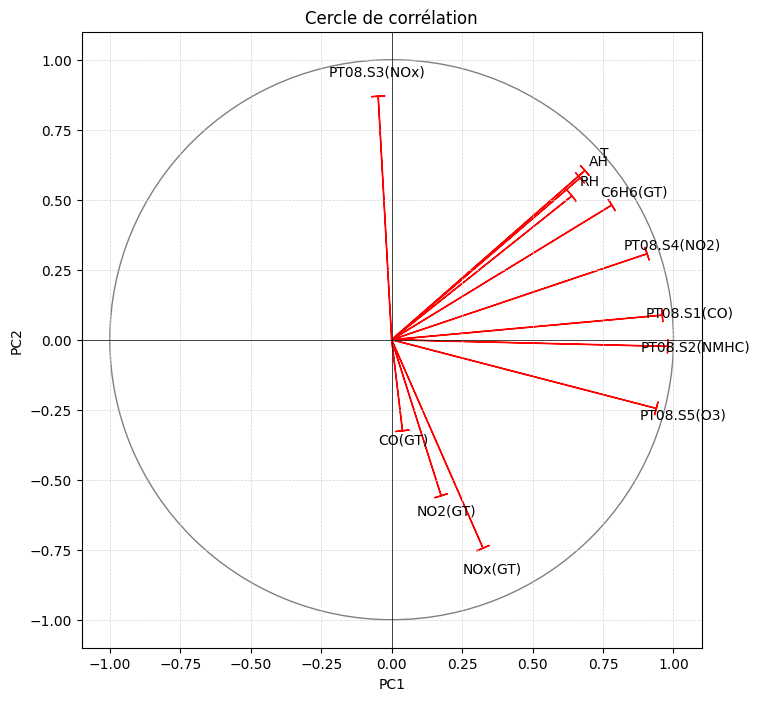

In [33]:
plot_correlation_circle(df,projete,df.columns)

Ce cercle de corrélation permet de visualiser les relations entre les différentes variables. On observe que les variables correspondant aux mesures réelles de pollution (CO(GT), NO2(GT), NOx(GT), etc.) sont fortement corrélées entre elles, ce qui suggère une origine commune.

De plus, les capteurs associés (PT08.S1, PT08.S2, etc.) sont orientés dans des directions proches de ces variables, ce qui indique qu’ils mesurent correctement les concentrations correspondantes.

Un troisième groupe peut être distingué, composé des variables environnementales (T, AH, RH), qui sont proches entre elles et traduisent les conditions climatiques.

## Analyse plus détaillé des corrélation entre nos données

In [34]:
report = tr(df)
report

Processing column  12 / 12


,,,,,,,,,,,,


L’analyse des associations confirme les relations observées précédemment, notamment la forte corrélation entre les variables environnementales T, RH et AH.

On observe également que les capteurs présentent des corrélations importantes avec les variables environnementales, ce qui suggère qu’ils sont sensibles aux conditions climatiques.

Par ailleurs, les capteurs sont aussi corrélés aux mesures réelles de pollution, ce qui indique qu’ils capturent une partie de l’information recherchée. Toutefois, ces corrélations ne sont pas parfaites, ce qui peut s’expliquer par le bruit de mesure ou l’influence de facteurs externes.

## Description des données 

L’analyse des distributions montre que les variables environnementales (T, RH, AH) présentent des distributions proches d’une loi gaussienne.

En revanche, les variables liées à la pollution présentent des distributions plus asymétriques, avec la présence de valeurs extrêmes.

On observe également un grand nombre de valeurs égales à -200, correspondant aux valeurs manquantes dans le dataset.

## Distribution des données

La partie distribution nous montre que nos variables environnementales ont une distribution gaussienne.

Tandis que nos autres valeurs sont un peu plus aléatoires.

On remarque aussi que beaucoup de données sont égales à -200, ce qui correspond à nos valeurs manquantes.

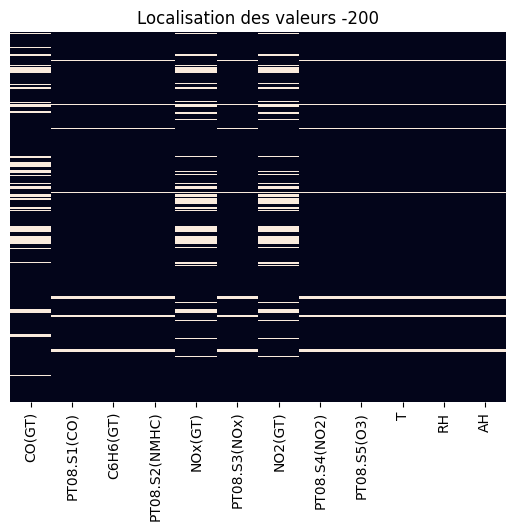

In [35]:
sns.heatmap((df == -200), cbar=False, yticklabels=False)
plt.title("Localisation des valeurs -200")# Les -200 sont équivalents à nos valeurs nulles
plt.show()

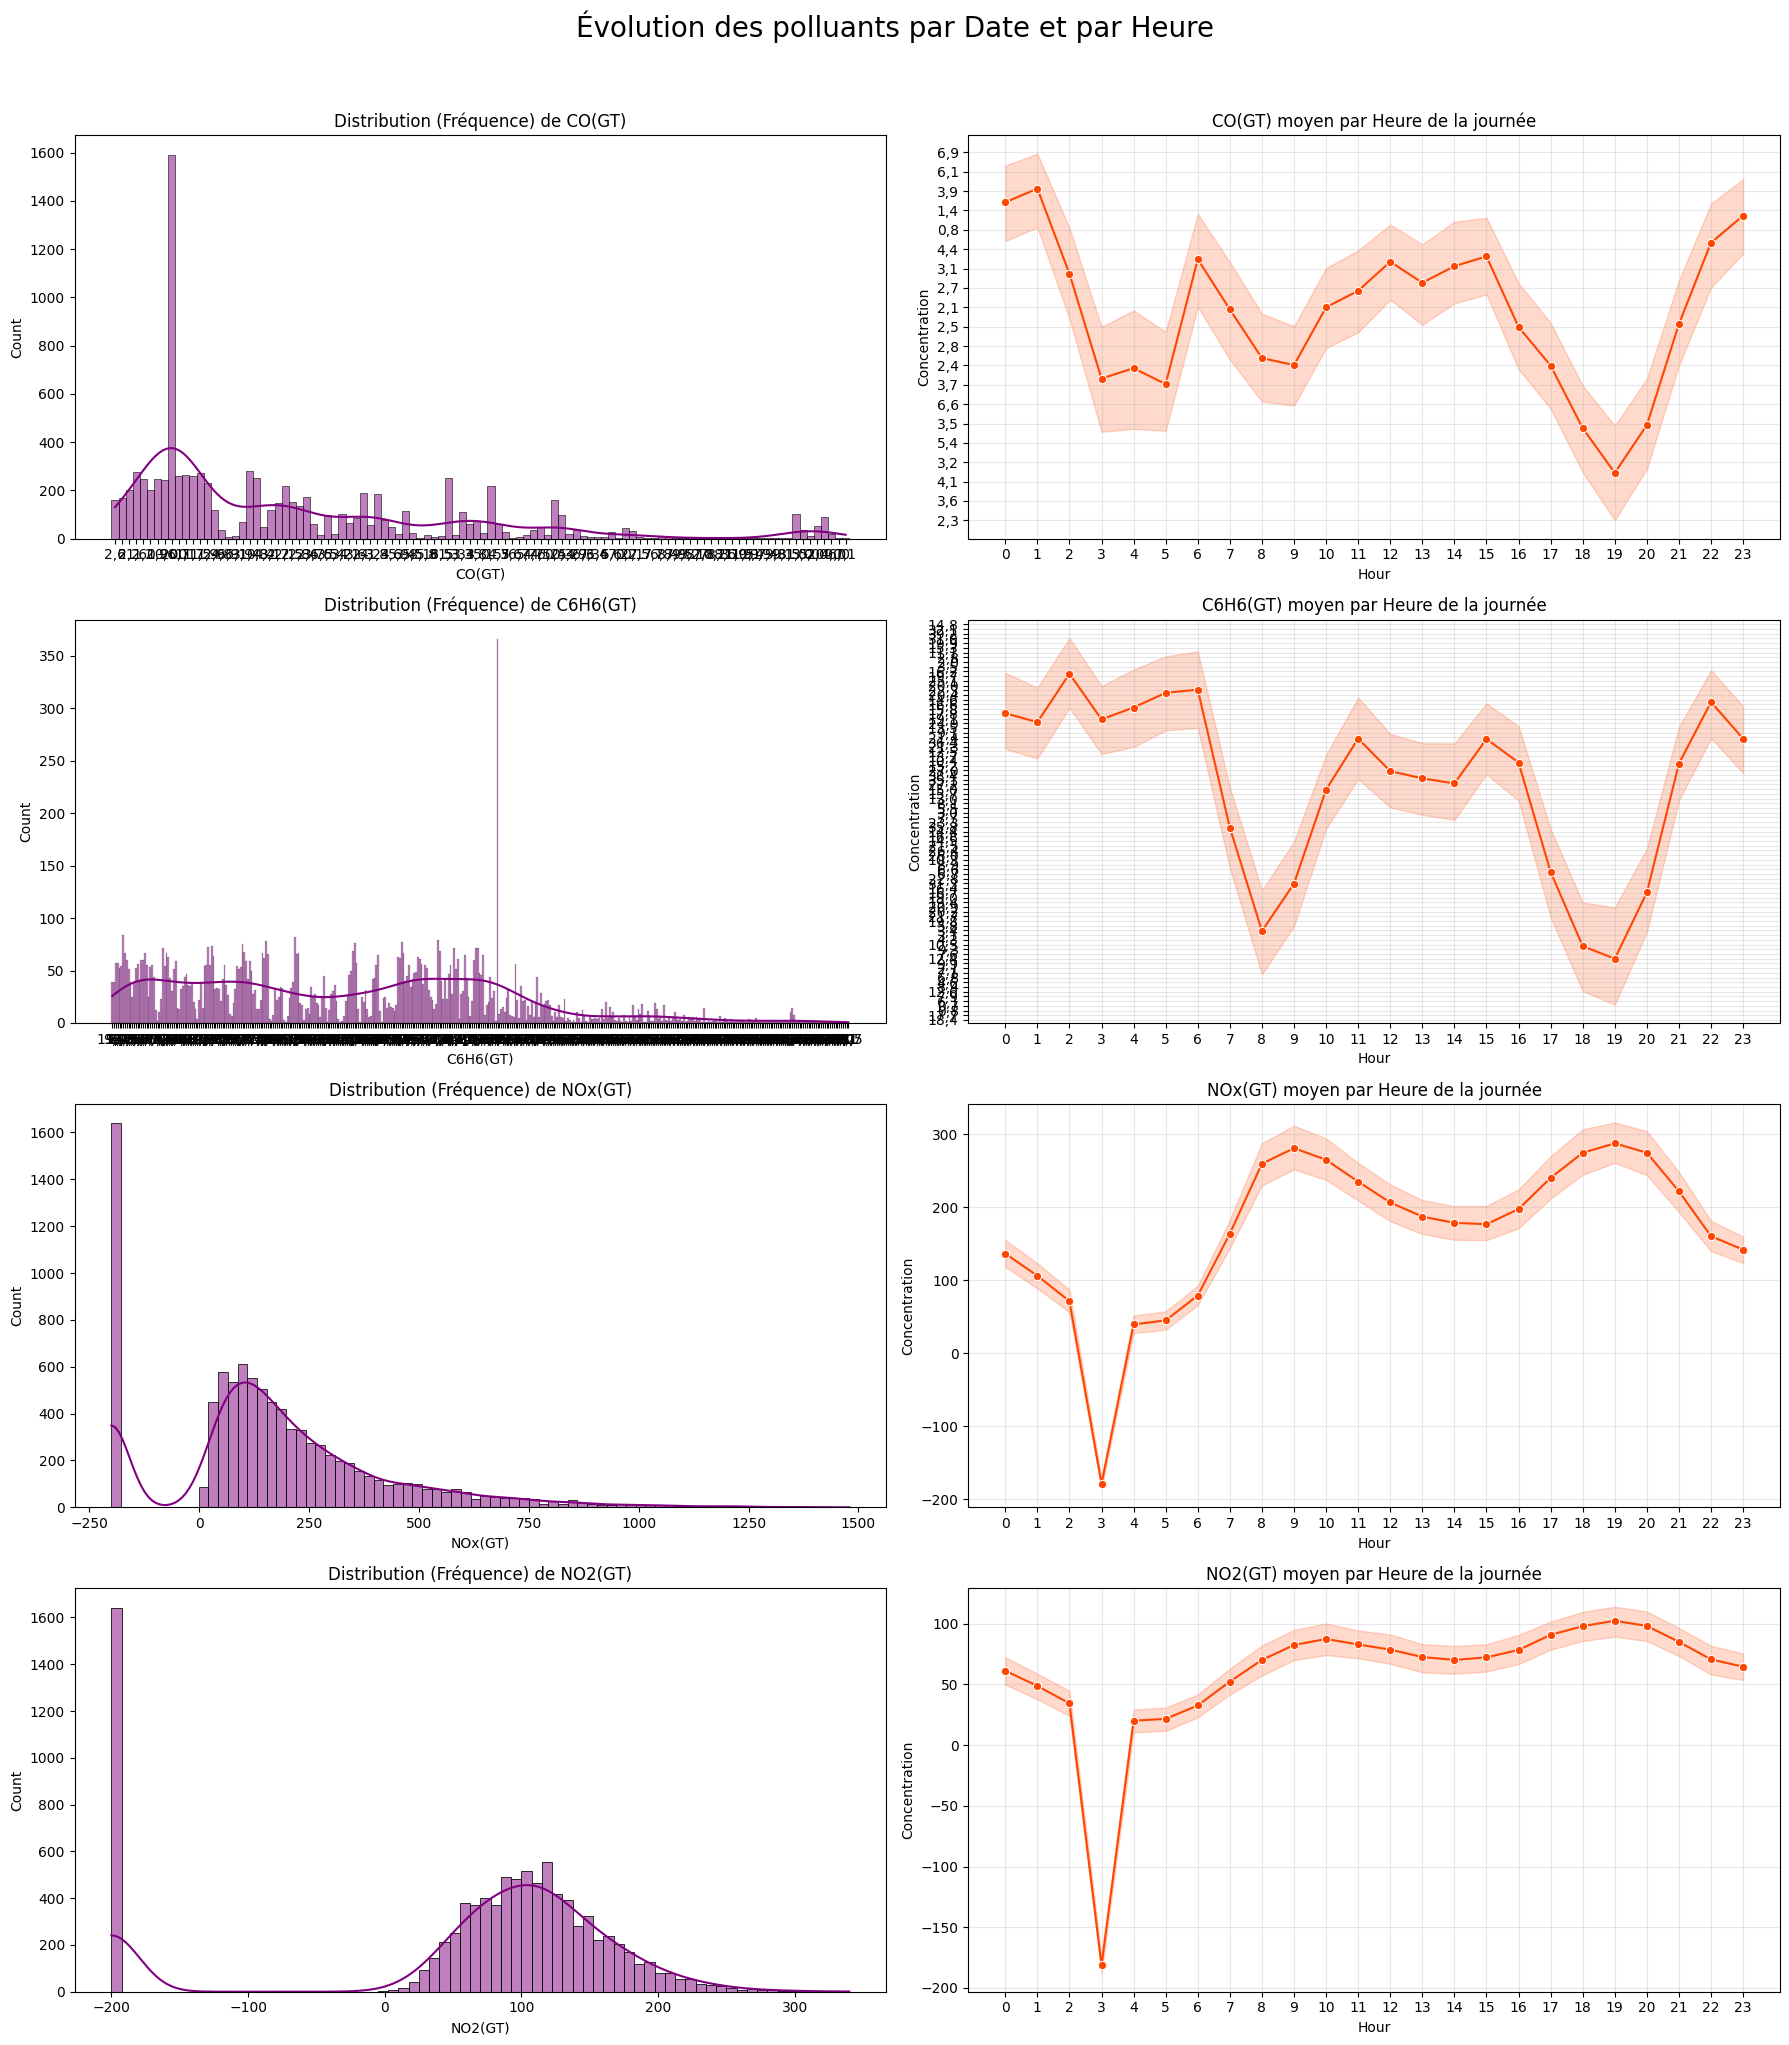

<Figure size 640x480 with 0 Axes>

In [44]:
# Liste de vos variables cibles
targets = ['CO(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']

# 1. Préparation des données (Assurez-vous d'avoir converti Date et Time)
df_plot = df_temp
df_plot['Date_dt'] = pd.to_datetime(df_plot['Date'])
# Extraction de l'heure seule pour le deuxième groupe de plots
df_plot['Hour'] = pd.to_datetime(df_plot['Time'], format='%H.%M.%S').dt.hour

# 2. Création de la figure (4 lignes pour les variables, 2 colonnes pour Date/Time)
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(18, 20))
fig.suptitle('Évolution des polluants par Date et par Heure', fontsize=20, y=1.02)

for i, var in enumerate(targets):
    # Histogramme( pour la date
    # Pour voir la "forme" de vos données et les outliers
    sns.histplot(df_plot[var], kde=True, ax=axes[i, 0], color='purple')
    axes[i, 0].set_title(f'Distribution (Fréquence) de {var}')
    
    #Évolution en fonction de TIME (Heure) ---
    sns.lineplot(ax=axes[i, 1], x='Hour', y=var, data=df_plot, color='orangered', marker='o')#sns calcule la moyenne à chaque heure
    axes[i, 1].set_title(f'{var} moyen par Heure de la journée')
    axes[i, 1].set_xticks(range(0, 24))
    axes[i, 1].set_ylabel('Concentration')
    axes[i, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.tight_layout()
plt.show()

Les distributions observées présentent des formes différentes selon les variables. Certaines, comme NO2, semblent relativement symétriques et peuvent évoquer une distribution proche d’une loi normale, tandis que d’autres, comme NOx, présentent une forte asymétrie avec une queue à droite qui ressemble alors à une loi poisson.

Cela suggère que les variables ne suivent pas toutes le même type de distribution, ce qui peut influencer le choix des modèles utilisés.

Certaines variables ne présentent pas de structure particulière au niveau de leur distribution globale. Cependant, cela ne signifie pas qu’elles sont indépendantes du temps.

En effet, l’analyse des concentrations moyennes en fonction de l’heure de la journée met en évidence une variation systématique pour l’ensemble des polluants. On observe notamment deux pics marqués, le matin et en fin de journée, ce qui correspond probablement aux périodes de forte activité humaine, notamment le trafic routier.

Cela montre que l’heure de la journée est une variable explicative importante dans la prédiction des concentrations de polluants.

Par ailleurs, les valeurs égales à -200 correspondant à des données manquantes ont été écartées afin de ne pas biaiser l’analyse.

Enfin, les distributions observées sont souvent asymétriques et éloignées d’une loi normale, ce qui suggère que des modèles non linéaires pourraient être plus adaptés pour capturer la structure des données.

In [12]:
df= df.replace(-200, np.nan)
cols_to_predict = ['CO(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)']
y = df.loc[:,cols_to_predict]
X = df.drop(columns=[ "C6H6(GT)", "NOx(GT)", "NO2(GT)", "CO(GT)"])

mask = y.notna().all(axis=1)#Tableau avec True si label présent False sinon
X, y = X[mask], y[mask]

# Partie prédiction

In [14]:
X_train, X_temp, y_train, y_temp = train_test_split(
X, y, test_size=0.30, shuffle=True, random_state=77
)

# 13% val / 17% test
X_val, X_test, y_val, y_test = train_test_split(
X_temp, y_temp, test_size=0.17/0.30, shuffle=True, random_state=77
)
display(X)
display(y)

,PT08.S1(CO),PT08.S2(NMHC),PT08.S3(NOx),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,1360.0,1046.0,1056.0,1692.0,1268.0,13.6,48.9,0.7578
1,1292.0,955.0,1174.0,1559.0,972.0,13.3,47.7,0.7255
2,1402.0,939.0,1140.0,1555.0,1074.0,11.9,54.0,0.7502
3,1376.0,948.0,1092.0,1584.0,1203.0,11.0,60.0,0.7867
4,1272.0,836.0,1205.0,1490.0,1110.0,11.2,59.6,0.7888
...,...,...,...,...,...,...,...,...
9352,1314.0,1101.0,539.0,1374.0,1729.0,21.9,29.3,0.7568
9353,1163.0,1027.0,604.0,1264.0,1269.0,24.3,23.7,0.7119
9354,1142.0,1063.0,603.0,1241.0,1092.0,26.9,18.3,0.6406
9355,1003.0,961.0,702.0,1041.0,770.0,28.3,13.5,0.5139


,CO(GT),C6H6(GT),NOx(GT),NO2(GT)
0,2.6,11.9,166.0,113.0
1,2.0,9.4,103.0,92.0
2,2.2,9.0,131.0,114.0
3,2.2,9.2,172.0,122.0
4,1.6,6.5,131.0,116.0
...,...,...,...,...
9352,3.1,13.5,472.0,190.0
9353,2.4,11.4,353.0,179.0
9354,2.4,12.4,293.0,175.0
9355,2.1,9.5,235.0,156.0


# Regression Linéaire

Une régression linéaire simple, c’est-à-dire sans pénalisation (type Ridge ou Lasso), consiste simplement à trouver l’argmin de :

$\frac{1}{n} \ || Y - X\theta ||$

Cette régression ne dépend alors d’aucun hyperparamètre, y compris avec sklearn.

In [15]:
pipe_lr = Pipeline([
("imputer", SimpleImputer(strategy="mean")), # gère les NaN
("scaler", StandardScaler()),
("model", LinearRegression())
])
pipe_lr.fit(X_train, y_train)

,steps,"[('imputer', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'mean'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,copy,True


In [16]:
y_val_pred = pipe_lr.predict(X_val)
y_test_pred = pipe_lr.predict(X_test)
mae_val = mean_absolute_error(y_val, y_val_pred)
mse_val = mean_squared_error(y_val, y_val_pred)
rmse_val = np.sqrt(mse_val)
r2_val = r2_score(y_val, y_val_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_test_pred)
print("=== Validation ===")
print("MAE :", mae_val)
print("MSE :", mse_val)
print("RMSE:", rmse_val)
print("R2 :", r2_val)
print("\n=== Test ===")
print("MAE :", mae_test)
print("MSE :", mse_test)
print("RMSE:", rmse_test)
print("R2 :", r2_test)

=== Validation ===
MAE : 19.18597505699882
MSE : 1701.8310872985228
RMSE: 41.253255475156415
R2 : 0.8545305864218898

=== Test ===
MAE : 19.337765814429673
MSE : 1731.9037219250558
RMSE: 41.61614737004203
R2 : 0.8710388872612361


## Interprétation de l'erreur

Le score Mean Absolute Error (MAE) correspond à $\frac{1}{n} \sum \left|y - y_{pred} \right|$.
Ce score est plus robuste que le MSE, car il est moins sensible aux outliers.

Nous obtenons un score de 19, ce qui est petit comparé au MSE, qui est d’environ 1700.
Ce score est donc correct, mais attendons de le comparer avec les autres régressions.
De plus, le R² est proche de 1, ce qui est bien (le modèle explique correctement les données).

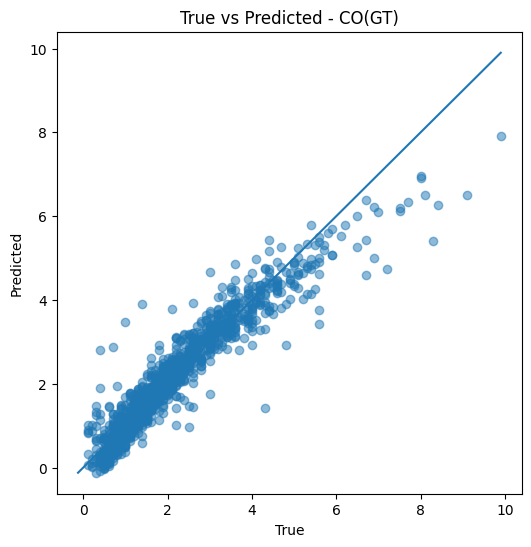

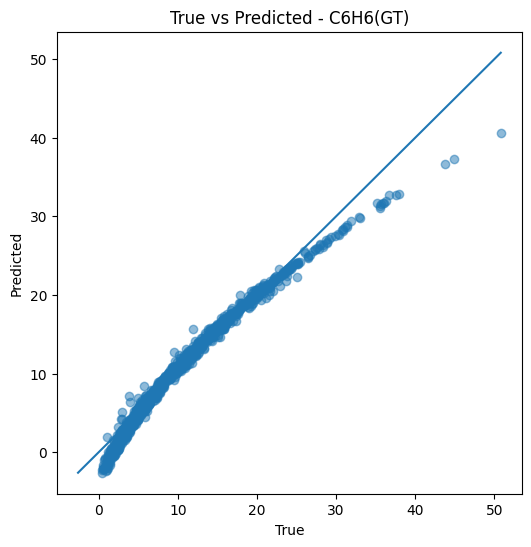

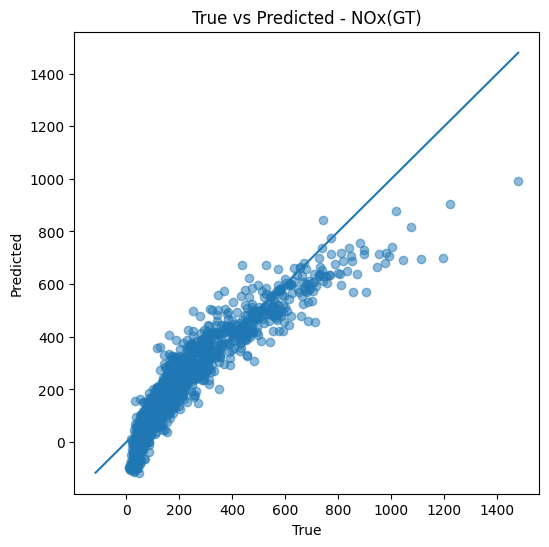

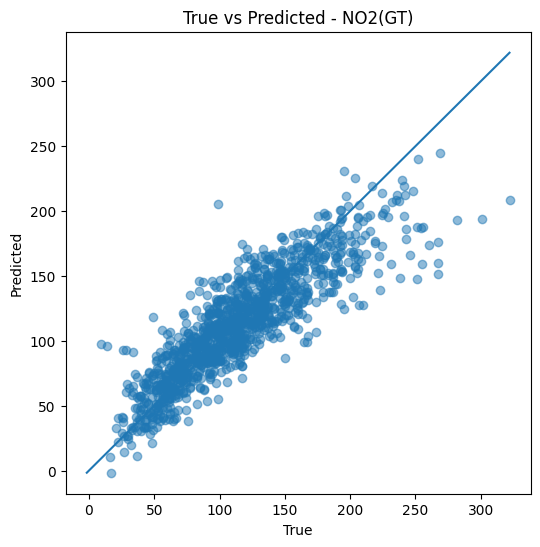

In [17]:
#Visualisation de notre prédiction pour chacune de nos variables

for i, col in enumerate(y.columns):
    plt.figure(figsize=(6, 6))
    plt.scatter(y_test.iloc[:, i], y_test_pred[:, i], alpha=0.5)
    mn = min(y_test.iloc[:, i].min(), y_test_pred[:, i].min())
    mx = max(y_test.iloc[:, i].max(), y_test_pred[:, i].max())
    plt.plot([mn, mx], [mn, mx])
    plt.xlabel("True")
    plt.ylabel("Predicted")
    plt.title(f"True vs Predicted - {col}")
    plt.show()

# Ridge regression

La régression avec pénalisation de Ridge correspond à une minimisation de notre fonction précédente
avec une fonction de pénalisation que l’on définira en bas.

Cette pénalisation nous permet d’éviter que notre modèle soit trop proche
de nos données d’entraînement (overfitting).

On cherche donc à trouver l’argmin de la fonction $ \theta \rightarrow \frac{1}{n} \ || Y - X\theta || + \lambda ||\theta||_2^2$.

On a donc un paramètre $ \lambda $ qui intervient dans notre régression. Plus notre $ \lambda $ est grand, plus le biais de notre estimateur sera élevé,
et donc moins le risque d’overfitting est élevé.

Cependant, si notre paramètre est élevé, le terme de variance sera plus proche de 0. On doit donc trouver un juste milieu.

Dans scikit-learn, ce paramètre est appelé alpha.

In [18]:
n = 50
alphas = np.logspace(-10, 1, n)
pipe_ridge = Pipeline([
("imputer", SimpleImputer(strategy="mean")), # gère les NaN
("scaler", StandardScaler()),
("model", Ridge())
])

In [19]:
lst_mse = []
for i in range(n):
    pipe_ridge.set_params(model__alpha=alphas[i])
    pipe_ridge.fit(X_train, y_train)
    y_val_pred = pipe_ridge.predict(X_val)
    mse_val = mean_squared_error(y_val, y_val_pred)
    lst_mse.append([alphas[i], mse_val])
lst_mse = np.array(lst_mse)
index_du_min = np.argmin(lst_mse[:, 1])

In [20]:
print(f'Le meilleur alpha est {lst_mse[index_du_min][0]} et a pour mse sur les données de validation {lst_mse[index_du_min][1]}')

Le meilleur alpha est 3.556480306223136 et a pour mse sur les données de validation 1701.6129079855575


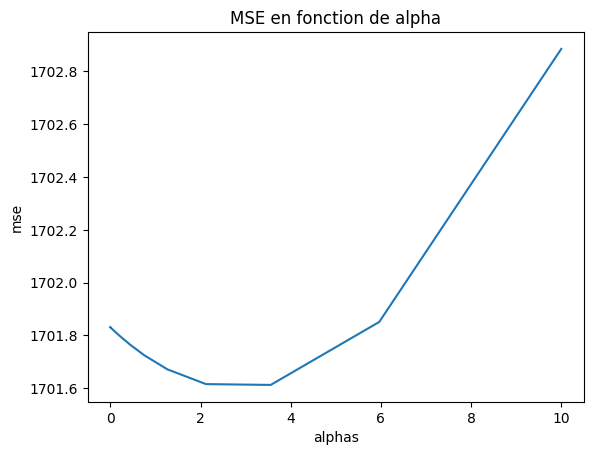

In [21]:
plt.plot(lst_mse[:,0],lst_mse[:,1])
plt.xlabel("alphas")
plt.ylabel("mse")
plt.title('MSE en fonction de alpha')
plt.show()

Cette courbe nous permet de bien comprendre l’enjeu biais-variance expliqué plus haut.

In [22]:
alpha_ridge = lst_mse[index_du_min][0]
pipe_ridge.set_params(model__alpha=alpha_ridge)
pipe_ridge.fit(X_train, y_train)

y_val_pred = pipe_ridge.predict(X_val)
y_test_pred = pipe_ridge.predict(X_test)
mae_val = mean_absolute_error(y_val, y_val_pred)
mse_val = mean_squared_error(y_val, y_val_pred)
rmse_val = np.sqrt(mse_val)
r2_val = r2_score(y_val, y_val_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_test_pred)
print("=== Validation ===")
print("MAE :", mae_val)
print("MSE :", mse_val)
print("RMSE:", rmse_val)
print("R2 :", r2_val)
print("\n=== Test ===")
print("MAE :", mae_test)
print("MSE :", mse_test)
print("RMSE:", rmse_test)
print("R2 :", r2_test)

=== Validation ===
MAE : 19.182944577744177
MSE : 1701.6129079855575
RMSE: 41.250611001360426
R2 : 0.8545298995120726

=== Test ===
MAE : 19.344309989126323
MSE : 1734.4539491587598
RMSE: 41.64677597556334
R2 : 0.8709479628463737


Sensiblement les mêmes scores qu’avec une régression linéaire.

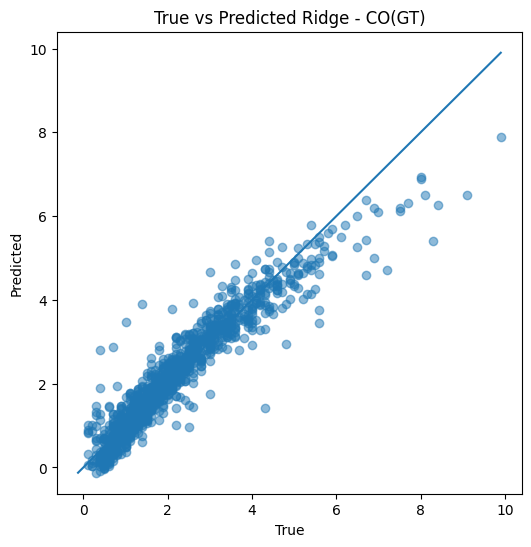

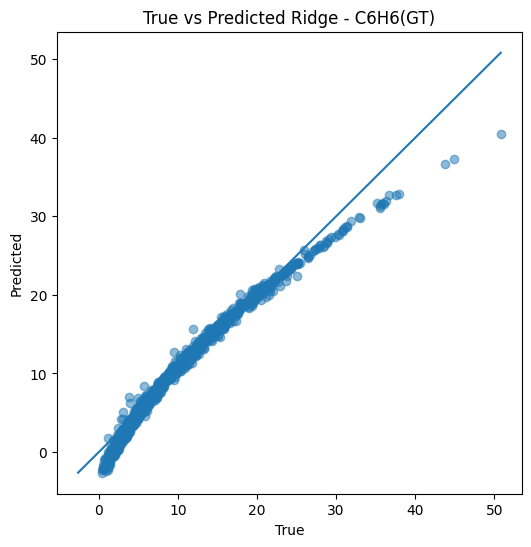

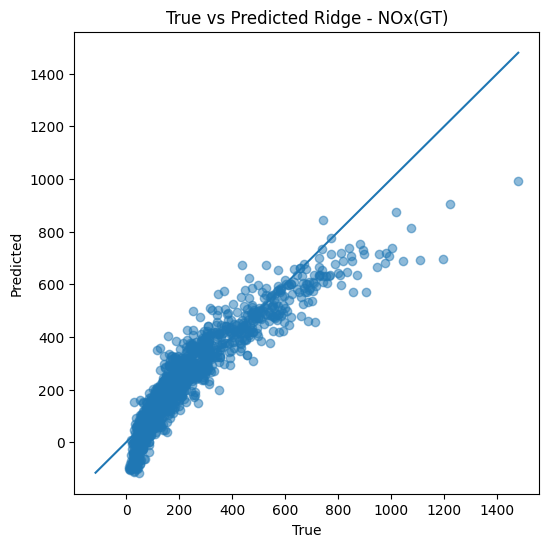

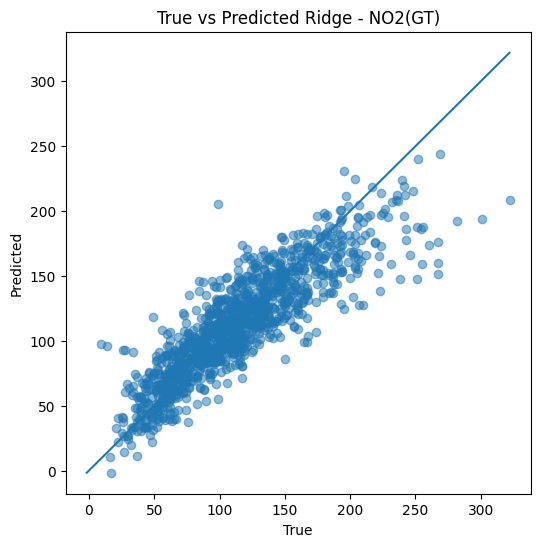

In [23]:
for i, col in enumerate(y.columns):
    plt.figure(figsize=(6, 6))
    plt.scatter(y_test.iloc[:, i], y_test_pred[:, i], alpha=0.5)
    mn = min(y_test.iloc[:, i].min(), y_test_pred[:, i].min())
    mx = max(y_test.iloc[:, i].max(), y_test_pred[:, i].max())
    plt.plot([mn, mx], [mn, mx])
    plt.xlabel("True")
    plt.ylabel("Predicted")
    plt.title(f"True vs Predicted Ridge - {col}")
    plt.show()

La courbure apparaissant dans nos plots est sûrement due à la non-linéarité de nos données. En effet, Ridge cherche à approximer la relation par une droite, ce qui est insuffisant lorsque la vraie relation est non-linéaire, il se trompe alors systématiquement, surtout sur les valeurs extrêmes.

# Lasso Regression

La régression avec pénalisation de Lasso est une minimisation du même genre que précédemment. Sauf que l’on change notre fonction
de pénalisation.

On cherche donc à trouver l’argmin de la fonction $ \theta \rightarrow \frac{1}{n} \ || Y - X\theta || + \lambda ||\theta||_1$.

Cette nouvelle pénalisation va shrinker nos données et mettre certains de nos coefficients à 0 lorsqu’ils sont assez proches de celui-ci.
Ridge, quant à lui, va les réduire mais ne les mettra jamais à 0.

Ridge est donc moins agressive que Lasso.

Dans scikit-learn, ce paramètre est appelé alpha.

In [24]:
n = 100
alphas = np.logspace(-20, -1, n) 
pipe_lasso = Pipeline([
("imputer", SimpleImputer(strategy="mean")), # gère les NaN
("scaler", StandardScaler()),
("model", Lasso())
])

In [25]:
lst_mse = []
nb_zeros = []
for i in range(n):
    pipe_lasso.set_params(model__alpha=alphas[i])
    pipe_lasso.fit(X_train, y_train)
    y_val_pred = pipe_lasso.predict(X_val)
    coef = pipe_lasso.named_steps["model"].coef_
    nb_zeros.append((coef==0).sum())
    mse_val = mean_squared_error(y_val, y_val_pred)
    lst_mse.append([alphas[i], mse_val])
lst_mse = np.array(lst_mse)
index_du_min = np.argmin(lst_mse[:, 1])

In [26]:
print(f'Le meilleur alpha est {lst_mse[index_du_min][0]} et a pour mse sur les données de validation {lst_mse[index_du_min][1]}')

Le meilleur alpha est 3.0538555088334123e-13 et a pour mse sur les données de validation 1701.8310872985203


Choix du alpha très petit(proche de 0) donc pas beaucoup de coefficient seront mis à 0

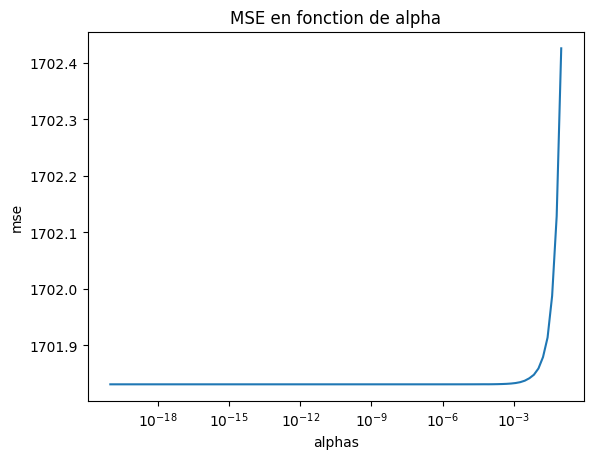

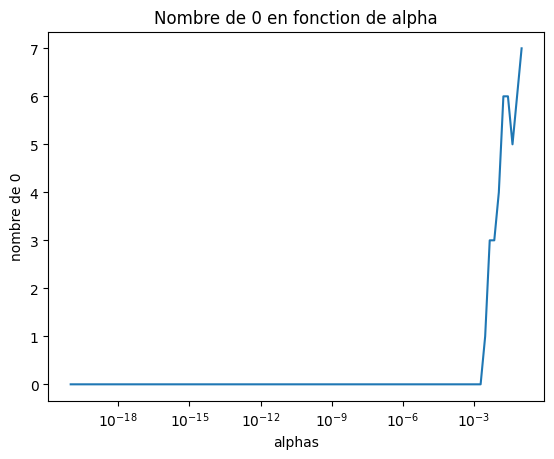

In [27]:
plt.plot(lst_mse[:,0],lst_mse[:,1])
plt.xlabel("alphas")
plt.ylabel("mse")
plt.xscale('log')
plt.title('MSE en fonction de alpha')
plt.show()

plt.plot(lst_mse[:,0],nb_zeros)
plt.xlabel("alphas")
plt.ylabel("nombre de 0")
plt.xscale('log')
plt.title('Nombre de 0 en fonction de alpha')
plt.show()

On a bien zéro coefficient égal à 0 pour notre choix d’alpha, avec l’erreur la plus faible que l’on pouvait obtenir.

In [28]:
alpha_lasso = lst_mse[index_du_min][0] 
pipe_lasso.set_params(model__alpha=alpha_lasso)
pipe_lasso.fit(X_train, y_train)

y_val_pred = pipe_lasso.predict(X_val)
y_test_pred = pipe_lasso.predict(X_test)
mae_val = mean_absolute_error(y_val, y_val_pred)
mse_val = mean_squared_error(y_val, y_val_pred)
rmse_val = np.sqrt(mse_val)
r2_val = r2_score(y_val, y_val_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_test_pred)
print("=== Validation ===")
print("MAE :", mae_val)
print("MSE :", mse_val)
print("RMSE:", rmse_val)
print("R2 :", r2_val)
print("\n=== Test ===")
print("MAE :", mae_test)
print("MSE :", mse_test)
print("RMSE:", rmse_test)
print("R2 :", r2_test)

=== Validation ===
MAE : 19.185975056998767
MSE : 1701.8310872985203
RMSE: 41.25325547515639
R2 : 0.8545305864218968

=== Test ===
MAE : 19.33776581442965
MSE : 1731.9037219250588
RMSE: 41.616147370042064
R2 : 0.8710388872612368


Étant donné que alpha est très petit, on se rapproche d’une régression linéaire sans pénalisation, donc ce n’est pas étonnant d’obtenir les mêmes scores.

# RKHS

Lorsque l’on fait une régression linéaire, on suppose que notre modèle est justement linéaire.
Les résultats que nous obtenions n’étaient pas mauvais mais pouvaient largement être améliorés.
On suppose donc désormais que notre modèle n’est pas linéaire.

On suppose que notre modèle est de la forme : $\forall i ,Y_i = f(X_i) + \epsilon_i $ où $\epsilon_i \sim \mathcal{N}(0,\,\sigma^{2})$

On cherche donc à estimer f et pour cela on va chercher l'argmin de la fonction suivante :

$\frac{1}{n}  \sum_{i=1}^n l(Y_i,f(X_i)) + \lambda ||f||_F^2$

Pour l une fonction de coût et F un espace de fonction à définir(on doit le réstreindre pour éviter l'overfitting).

Dans notre cas, on suppose que l'on a un espace RKHS de noyau k. 

Grâce au théorème du représentant,  toutes solutions de notre problème s'écrit :

$ f : x \rightarrow \sum_{i=1}^n \alpha_ik(X_i,x)$ où  $\alpha=(\alpha^1,...,\alpha^n)^T$ est sol de :

$\alpha \in argmin \frac{1}{n} \sum_{i=1}^n l(Y_i,(K\alpha)_i)) + \lambda \alpha^T K \alpha  $ 
où $K =(k(x_i,x_j))_{1<=i,j<=n} $



## Kernel Ridge Linear

On suppose que notre noyau $k$ est : $ k(x,y) = x^Ty $.
C’est-à-dire que notre modèle est le même que celui d’avant.

On a donc qu’un hyperparamètre $\alpha$ utilisé pour la pénalisation.

Notre fonction à minimiser ressemblera donc à celle utilisée pour Ridge.
On s’attend donc à avoir des résultats similaires.

In [29]:
from sklearn.compose import TransformedTargetRegressor

pipe_kr = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("model", TransformedTargetRegressor( #Obligé pour avoir les mêmes base que Ridge classique
        regressor=KernelRidge(kernel="linear"),
        transformer=StandardScaler()
    ))
])

param_grid = {
    "model__regressor__alpha": np.logspace(-4, 0, 5)
}

grid_search = GridSearchCV(
    pipe_kr,
    param_grid,
    scoring="neg_mean_squared_error",
    cv=5
)

grid_search.fit(X_train, y_train)

y_pred = grid_search.predict(X_test)

print("Meilleur alpha :", grid_search.best_params_)
print("MSE test :", mean_squared_error(y_test, y_pred))
print("CV MSE :", -grid_search.best_score_)

Meilleur alpha : {'model__regressor__alpha': np.float64(1.0)}
MSE test : 1732.557242853386
CV MSE : 1926.1393971844566


On obtient donc un MSE similaire à celui d'un ridge classique. Comme prévu.

## Kernel Ridge RBF

On va essayer de confirmer la non-linéarité de notre modèle que l’on avait soupçonnée avec Ridge.

Avec RBF, on suppose que le noyau $k$ est de la forme : $ k(x,y) = \exp(-\gamma || x - y ||^2)$ pour un $\gamma>0$.

Le noyau RBF est souvent choisi, car il est universel, capable d’approximer toute fonction continue, tout en restant simple à paramétrer via un unique paramètre $\gamma$.

On se retrouve donc à tuner deux hyperparamètres : $\alpha$ et $\gamma$.

In [30]:
pipe_rbf = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("model", KernelRidge(kernel="rbf"))
])

alpha_values = np.logspace(-4, 3, 20)
gamma_values = np.logspace(-4, 3, 20)

param_grid = {
    "model__alpha": alpha_values,
    "model__gamma": gamma_values
}

grid_search_rbf = GridSearchCV(
    pipe_rbf,
    param_grid,
    cv=3,
    n_jobs=-1,
    scoring="neg_mean_squared_error"
)

grid_search_rbf.fit(X_train, y_train)

print("Meilleurs paramètres :", grid_search_rbf.best_params_)
print("Meilleur score CV MSE :", -grid_search_rbf.best_score_)

y_test_pred = grid_search_rbf.predict(X_test)
print("MSE test :", mean_squared_error(y_test, y_test_pred))

Meilleurs paramètres : {'model__alpha': np.float64(0.0069519279617756054), 'model__gamma': np.float64(0.08858667904100823)}
Meilleur score CV MSE : 791.5081945894802
MSE test : 689.5630087951349


In [31]:
r2 = r2_score(y_test, y_test_pred)
print("R2 test :", r2)

R2 test : 0.9331914574990738


On obtient de bien meilleur score qu'avec un modèle linéaire.

Traçons une heat map afin de voir l'influence des paramètres sur notre modèles

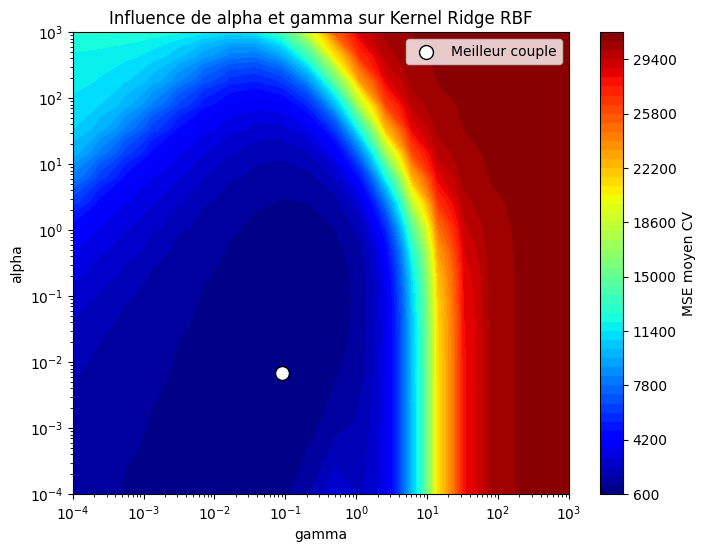

In [32]:
mean_scores = grid_search_rbf.cv_results_["mean_test_score"]

Z = np.array(mean_scores).reshape(len(alpha_values), len(gamma_values))

X, Y = np.meshgrid(gamma_values, alpha_values)

plt.figure(figsize=(8, 6))
contour = plt.contourf(X, Y, -Z, levels=50, cmap="jet")
plt.colorbar(contour, label="MSE moyen CV")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("gamma")
plt.ylabel("alpha")
plt.title("Influence de alpha et gamma sur Kernel Ridge RBF")

best_alpha = grid_search_rbf.best_params_["model__alpha"]
best_gamma = grid_search_rbf.best_params_["model__gamma"]

plt.scatter(best_gamma, best_alpha, color="white", edgecolors="black", s=100, label="Meilleur couple")
plt.legend()
plt.show()

On remarque que notre régression va chercher à ne pas trop pénaliser, donc on sera assez proche de nos données d’entraînement.
Notre gamma n’étant pas très petit, on se rend compte que notre modèle n’est pas très linéaire.

Cependant, il n’en est pas loin non plus, car s’il était trop grand, notre erreur exploserait.

Cela explique pourquoi on n’avait pas un trop mauvais score avec des modèles linéaires.

# Réseau de neuronnes dense

$ \forall i , (X_i,Y_i) \in \mathbb{R}^d\times\mathbb{R}^M$

On suppose que notre modèle est de la forme : $ \forall i, Y_i = f_*(X_i) + \epsilon_i $.

Où $f_*$ est une fonction inconnue à approcher et les $(\epsilon_i)_{1 \leq i \leq n}$ sont i.i.d. gaussiennes centrées.

L'intérêt d'un réseau de neurones se situe dans le cas où l'on suppose que la fonction à approcher n'est pas linéaire.

On le construit ainsi :

$ h_{\theta}^0(X_i) = X_i$

$ z_{\theta}^k(X_i) = W^k h_{\theta}^{k-1}(X_i) + b^k$ pour $1 \leq k \leq L$

$ h_{\theta}^k(X_i) = \varphi_k(z_{\theta}^k(X_i)) $

Avec $W^k \in \mathbb{R}^{d_k \times d_{k-1}}$ et $b^k \in \mathbb{R}^{d_k}$, où $d_k$ correspond au nombre de neurones de la couche $k$, et $L$ au nombre de couches.

Les fonctions $\varphi_k$ introduisent la non-linéarité du modèle.

On cherche donc à estimer $\theta = {W^1, b^1, \dots, W^L, b^L}$.

Des algorithmes de descente de gradient permettent d'estimer ces paramètres.

On a $ \theta \leftarrow \theta - \eta \nabla \ell(\theta)$, où $\eta$ est un hyperparamètre correspondant au learning rate.

À cela, on ajoute l'hyperparamètre correspondant au nombre d'epochs. Une epoch correspond à un passage complet sur l’ensemble des données d’entraînement, au cours duquel le modèle met à jour ses paramètres une ou plusieurs fois selon la méthode de descente de gradient utilisée.

On se retrouve alors avec plusieurs hyperparamètres à choisir : le learning rate, le nombre de couches, le nombre de neurones ainsi que le nombre d'epochs.

Nous optimisons séquentiellement par souci de coût calculatoire. Cette approche suppose une faible interaction entre les hyperparamètres, ce qui est une approximation. Cependant, l'idéal aurait été de réaliser un grid search ou un randomized search.

In [35]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

I0000 00:00:1777274214.590423    4367 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [37]:
# Imputation
imputer = SimpleImputer(strategy="mean")
X_train_imp = imputer.fit_transform(X_train)
X_val_imp = imputer.transform(X_val)
X_test_imp = imputer.transform(X_test)
# Standardisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_val_scaled = scaler.transform(X_val_imp)
X_test_scaled = scaler.transform(X_test_imp)

In [38]:
def create_model(input_dim, nb_neurones=50, nb_couches=1, learning_rate=1e-3):
    model = Sequential()
    
    # Première couche cachée
    model.add(Dense(nb_neurones, activation='relu', input_shape=(input_dim,)))
    
    # Couches cachées supplémentaires
    for _ in range(nb_couches - 1):
        model.add(Dense(nb_neurones, activation='relu'))
    
    # Couche de sortie
    model.add(Dense(4))#Prédire les 4 variables en meme temps
    
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mse')
    
    return model

In [39]:
def eval_model(params, X_train, y_train, X_val, y_val, epochs=100, batch_size=32):
    model = create_model(
        input_dim=X_train.shape[1],
        nb_neurones=params["nb_neurones"],
        nb_couches=params["nb_couches"],
        learning_rate=params["learning_rate"]
    )
    
    model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        verbose=0
    )
    
    y_val_pred = model.predict(X_val, verbose=0)
    mse_val = mean_squared_error(y_val, y_val_pred)
    
    return mse_val

In [40]:
fixed_params = {
    "nb_neurones": 50,
    "nb_couches": 1,
    "learning_rate": 1e-3
}

In [41]:
valeurs_neurones = [10, 20, 50, 100, 200, 300, 500]
valeurs_couches = [1, 2, 3, 4, 5, 7, 10]

res_archi = []

for nb_couches in valeurs_couches:
    for nb_neurones in valeurs_neurones:
        params = fixed_params.copy()
        params["nb_couches"] = nb_couches
        params["nb_neurones"] = nb_neurones
        
        mse = eval_model(
            params,
            X_train_scaled, y_train,
            X_val_scaled, y_val,
            epochs=100,
            batch_size=32
        )
        
        res_archi.append([nb_couches, nb_neurones, mse])

res_archi = np.array(res_archi)

index_best = np.argmin(res_archi[:, 2])
best_nb_couches = int(res_archi[index_best, 0])
best_nb_neurones = int(res_archi[index_best, 1])

fixed_params["nb_couches"] = best_nb_couches
fixed_params["nb_neurones"] = best_nb_neurones

print("Meilleur nombre de couches :", best_nb_couches)
print("Meilleur nombre de neurones :", best_nb_neurones)
print("MSE :", res_archi[index_best, 2])

/home/valentin/Bureau/abd/.venv/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1777274218.474968    4367 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/home/valentin/Bureau/abd/.venv/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/valentin/Bureau/abd/.venv/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim`

Meilleur nombre de couches : 3
Meilleur nombre de neurones : 500
MSE : 688.9628295898438


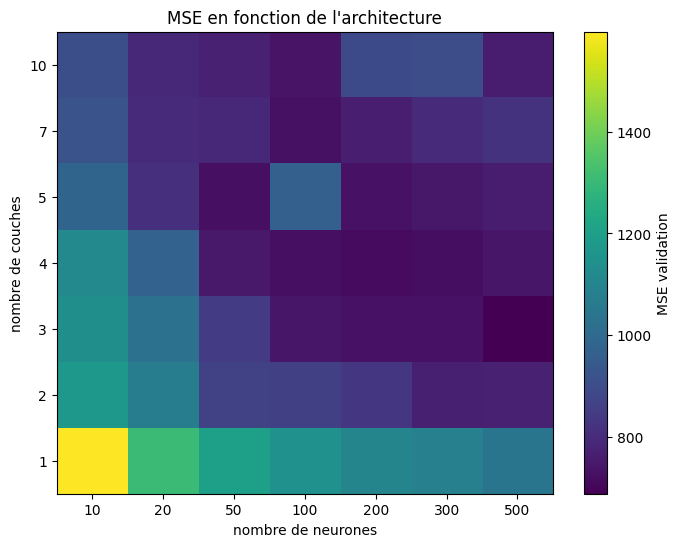

In [42]:
Z = res_archi[:, 2].reshape(len(valeurs_couches), len(valeurs_neurones))

plt.figure(figsize=(8, 6))
plt.imshow(Z, aspect="auto", origin="lower")
plt.colorbar(label="MSE validation")
plt.xticks(range(len(valeurs_neurones)), valeurs_neurones)
plt.yticks(range(len(valeurs_couches)), valeurs_couches)
plt.xlabel("nombre de neurones")
plt.ylabel("nombre de couches")
plt.title("MSE en fonction de l'architecture")
plt.show()

Cette heatmap met en évidence l’existence d’un compromis entre le nombre de couches et le nombre de neurones.

On observe qu’une augmentation du nombre de neurones améliore globalement les performances du modèle, en permettant une meilleure capacité d’approximation. Toutefois, au-delà d’un certain seuil, les gains deviennent marginaux.

De même, une profondeur trop faible (une seule couche) conduit à de mauvaises performances, traduisant un sous-apprentissage. En revanche, augmenter excessivement le nombre de couches n’apporte pas d’amélioration significative, et peut même dégrader les performances en rendant l’optimisation plus difficile.

Enfin, les résultats montrent une interaction entre ces deux hyperparamètres : la performance dépend de leur combinaison, et non de chacun pris isolément.

Le meilleur modèle est obtenu pour une architecture composée de 3 couches et 500 neurones, ce qui correspond à un bon compromis entre capacité d’apprentissage et complexité du modèle.

/home/valentin/Bureau/abd/.venv/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/valentin/Bureau/abd/.venv/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/valentin/Bureau/abd/.venv/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init

Meilleur learning rate : 0.00379269019073225
MSE : 650.4764404296875


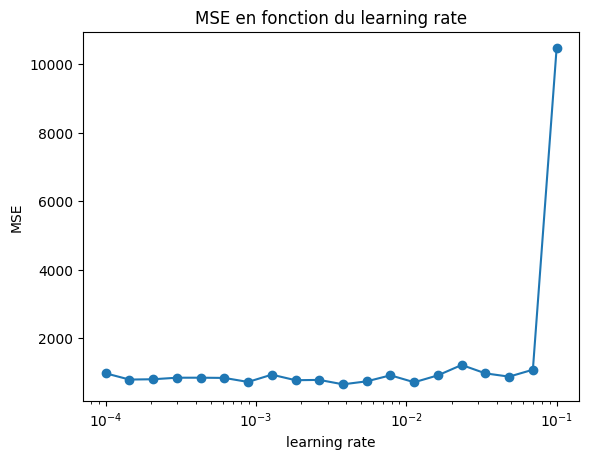

In [43]:
learning_rates = np.logspace(-4, -1, 20)

res_lr = []

for lr in learning_rates:
    params = fixed_params.copy()
    params["learning_rate"] = lr
    
    mse = eval_model(
        params,
        X_train_scaled, y_train,
        X_val_scaled, y_val,
        epochs=100,
        batch_size=32
    )
    
    res_lr.append([lr, mse])

res_lr = np.array(res_lr)
best_lr = res_lr[np.argmin(res_lr[:, 1]), 0]


print("Meilleur learning rate :", best_lr)
print("MSE :", np.min(res_lr[:, 1]))

plt.plot(res_lr[:, 0], res_lr[:, 1], marker="o")
plt.xscale("log")
plt.xlabel("learning rate")
plt.ylabel("MSE")
plt.title("MSE en fonction du learning rate")
plt.show()

Ce graphique met en évidence l’influence du learning rate sur les performances du modèle.

On observe une zone de bonnes performances pour des valeurs comprises entre $10^{-3}$ et $10^{-2}$.
(Désolé, je ne peux pas tracer le graphe sans les données en $10^{-1}$, qui ne le rendent pas lisible, mais j’ai modifié mon code au dernier moment et un recalcul de ces données prendrait trop de temps.)

Des valeurs trop faibles entraînent une convergence lente, tandis que des valeurs trop élevées rendent l’optimisation instable, ce qui dégrade les performances.

/home/valentin/Bureau/abd/.venv/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/valentin/Bureau/abd/.venv/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/valentin/Bureau/abd/.venv/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init

Meilleur nombre d'epochs : 200
MSE : 704.0387573242188


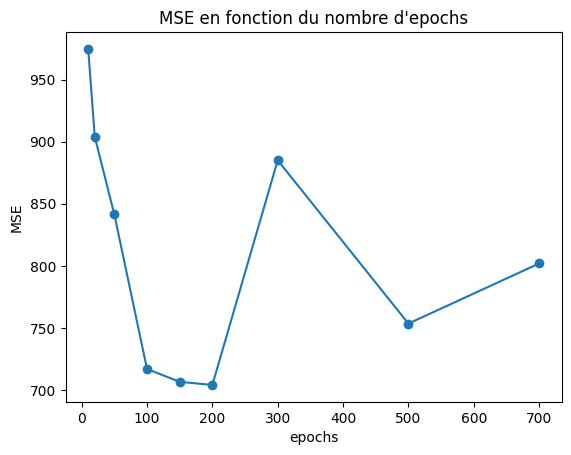

In [44]:
valeurs_epochs = [10, 20, 50, 100, 150, 200, 300, 500,700]

res_epochs = []

for ep in valeurs_epochs:
    mse = eval_model(
        fixed_params,
        X_train_scaled, y_train,
        X_val_scaled, y_val,
        epochs=ep,
        batch_size=32
    )
    
    res_epochs.append([ep, mse])

res_epochs = np.array(res_epochs)

best_epochs = int(res_epochs[np.argmin(res_epochs[:, 1]), 0])

print("Meilleur nombre d'epochs :", best_epochs)
print("MSE :", np.min(res_epochs[:, 1]))

plt.plot(res_epochs[:, 0], res_epochs[:, 1], marker="o")
plt.xlabel("epochs")
plt.ylabel("MSE")
plt.title("MSE en fonction du nombre d'epochs")
plt.show()

Ce graphique met en évidence l’influence du nombre d’epochs sur la performance du modèle.
On observe tout d’abord une diminution significative du MSE lorsque le nombre d’epochs augmente, ce qui traduit une amélioration progressive de l’apprentissage.
Le minimum est atteint autour de 200 epochs, indiquant un bon compromis entre apprentissage et généralisation.
Au-delà de cette valeur, le MSE augmente puis fluctue, ce qui peut traduire un début de surapprentissage ou une instabilité de l’optimisation.
Ainsi, un nombre d’epochs trop faible conduit à un sous-apprentissage, tandis qu’un nombre trop élevé n’améliore pas les performances et peut les dégrader.

In [45]:
final_model = create_model(
    input_dim=X_train_scaled.shape[1],
    nb_neurones=fixed_params["nb_neurones"],
    nb_couches=fixed_params["nb_couches"],
    learning_rate=fixed_params["learning_rate"]
)


final_model.fit(
    X_train_scaled, y_train,
    epochs=best_epochs,
    batch_size=32,
    verbose=0
)

y_test_pred = final_model.predict(X_test_scaled, verbose=0)

mse_test = mean_squared_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

print("Paramètres finaux :", fixed_params)
print("Epochs :", best_epochs)
print("MSE test :", mse_test)
print("R2 test :", r2_test)

/home/valentin/Bureau/abd/.venv/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Paramètres finaux : {'nb_neurones': 500, 'nb_couches': 3, 'learning_rate': 0.001}
Epochs : 200
MSE test : 587.4166259765625
R2 test : 0.9325671195983887


Nous obtenons des résultats encore meilleur qu'avec notre regression avec un kernel rbf.

La non linéarité de notre modèle est donc confirmer

# Comparaison des algorithmes

Nos modèles de régression linéaire, Ridge et Lasso obtiennent des performances similaires entre eux, ce qui s’explique par le fait que l’alpha optimal de Ridge et Lasso est très petit ; la pénalisation a donc peu d’effet et les trois modèles se comportent de façon quasi identique.

Les graphiques True vs Predicted révèlent une courbure systématique pour ces modèles : ils sous-estiment les valeurs élevées de chaque polluant. Cette courbure est la signature d’une relation non linéaire dans les données que ces modèles ne peuvent structurellement pas capturer.

C’est ce qui explique pourquoi le kernel Ridge RBF et le réseau de neurones dense obtiennent de bien meilleures performances. En modélisant des relations non linéaires, ils s’adaptent à la vraie structure des données. Le kernel RBF reste notre meilleur modèle au vu de ses performances et de sa complexité d’implémentation plus faible que celle du réseau de neurones.

Une piste d’amélioration naturelle serait d’utiliser un TimeSeriesSplit plutôt qu’un split aléatoire, car nos données sont des mesures horaires consécutives — la structure temporelle n’est pas exploitée dans notre approche actuelle.

# Amélioration de notre modèle

## TimeSeriesSplit

On ne sait pas à quel point la date et l’heure ont un impact sur notre modèle.
Et dans notre base de données, les données sont triées par date et heure.

Le problème de nos modèles actuels est que nos données X_train et X_test sont mélangées sans prendre en compte ces deux variables.
Le problème vient alors du fait que l’on essaie de prédire des variables en connaissant déjà le futur.

L’intérêt d’un time series split est justement de s’entraîner sur des variables passées, de valider sur des variables un peu plus récentes, puis de tester sur nos variables les plus récentes.

Afin de montrer l'amélioration de nos modèles avec cette façon de découper nos données. Nous allons refaire un modèle de regréssion avec kernel rbf car il obtenait de bon résultats sans être trop long à entrainer.

In [17]:
from sklearn.model_selection import TimeSeriesSplit

n = len(X)
test_size_1 = int(0.30 * n)
tscv = TimeSeriesSplit(n_splits=2, test_size=test_size_1)

train_idx, temp_idx = list(tscv.split(X))[-1]

X_train, X_temp = X.iloc[train_idx], X.iloc[temp_idx]
y_train, y_temp = y.iloc[train_idx], y.iloc[temp_idx]

test_size_2 = int((0.17 / 0.30) * len(X_temp))

X_val = X_temp.iloc[:-test_size_2]
X_test = X_temp.iloc[-test_size_2:]

y_val = y_temp.iloc[:-test_size_2]
y_test = y_temp.iloc[-test_size_2:]

In [22]:
pipe_rbf = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("model", KernelRidge(kernel="rbf"))
])

alpha_values = np.logspace(-4, 3, 20)
gamma_values = np.logspace(-4, 3, 20)

param_grid = {
    "model__alpha": alpha_values,
    "model__gamma": gamma_values
}


tscv_cv = TimeSeriesSplit(n_splits=3)

grid_search_rbf = GridSearchCV(
    pipe_rbf,
    param_grid,
    cv=tscv_cv,
    n_jobs=-1,
    scoring="neg_mean_squared_error"
)

grid_search_rbf.fit(X_train, y_train)

print("Meilleurs paramètres :", grid_search_rbf.best_params_)
print("Meilleur score CV MSE :", -grid_search_rbf.best_score_)

y_test_pred = grid_search_rbf.predict(X_test)

print("MSE test :", mean_squared_error(y_test, y_test_pred))
print("R2 test :", r2_score(y_test, y_test_pred))

Meilleurs paramètres : {'model__alpha': np.float64(0.00023357214690901214), 'model__gamma': np.float64(0.000545559478116852)}
Meilleur score CV MSE : 3580.172253169951
MSE test : 1749.583735782505
R2 test : 0.78426124294224


In [23]:
from sklearn.compose import TransformedTargetRegressor

pipe_kr = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("model", TransformedTargetRegressor( #Obligé pour avoir les mêmes base que Ridge classique
        regressor=KernelRidge(kernel="linear"),
        transformer=StandardScaler()
    ))
])

param_grid = {
    "model__regressor__alpha": np.logspace(-4, 0, 5)
}

tscv_cv = TimeSeriesSplit(n_splits=3)

grid_search = GridSearchCV(
    pipe_kr,
    param_grid,
    scoring="neg_mean_squared_error",
    cv=tscv_cv
)

grid_search.fit(X_train, y_train)

y_pred = grid_search.predict(X_test)

print("Meilleur alpha :", grid_search.best_params_)
print("MSE test :", mean_squared_error(y_test, y_pred))
print("CV MSE :", -grid_search.best_score_)

print("MSE test :", mean_squared_error(y_test, y_pred))
print("R2 test :", r2_score(y_test, y_pred))

Meilleur alpha : {'model__regressor__alpha': np.float64(0.0001)}
MSE test : 1938.4845336675344
CV MSE : 4527.605258464435
MSE test : 1938.4845336675344
R2 test : 0.7223695182239599


La baisse des performances de notre modèle s’explique par le fait que le découpage temporel impose une séparation stricte entre les données passées et futures. Contrairement à un découpage aléatoire, le modèle n’a plus accès à des informations issues du futur lors de l’entraînement, ce qui rend la tâche de prédiction plus réaliste mais également plus difficile.